<a href="https://colab.research.google.com/github/edilsonchaves/MVP-Analise-de-Dados-Oscar-Research/blob/main/OscarResearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Descrição do Tabalho**

Neste trabalho busca fazer um levantamento sobre a maior premiação do oscar desde a sua primeira edição que ocorreu no ano de 1929 referente a filmes lançados nos anos de 1927/1928 até a edição de numero 97 que ocorreu no ano de 2024.
<br><br>

# **Coleta de dados**

Os dados foram coletaods na plataforma kaggle no link : https://www.kaggle.com/datasets/unanimad/the-oscar-award e os dados brutos foram armazenados neste repositório git




# **Dados Brutos**

Na tabela subsequente é mostrado os dados brutos obtidos através do site com um total de 12014 entradas e 16 colunas.

In [702]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/edilsonchaves/MVP-Analise-de-Dados-Oscar-Research/refs/heads/main/oscar_full_data.csv"
df = pd.read_csv(url, sep="\t")
display(df)

,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination
0,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051251,The Noose,tt0019217,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,Nickie Elkins,NaN,NaN,True
1,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051252,The Patent Leather Kid,tt0018253,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,The Patent Leather Kid,NaN,NaN,True
2,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250a,The Last Command,tt0019071,Emil Jannings,Emil Jannings,nm0417837,True,General Dolgorucki [Grand Duke Sergius Alexander],NaN,NaN,True
3,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250b,The Way of All Flesh,tt0019553,Emil Jannings,Emil Jannings,nm0417837,True,August Schilling,NaN,NaN,True
4,1,1927/28,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,an0051255,A Ship Comes In,tt0018389,Louise Dresser,Louise Dresser,nm0237571,NaN,Mrs. Pleznik,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12009,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Dustin Brooks, Colin Decker",NaN,True,NaN,Fire for Hire's gel first publicly demonstrate...,To DUSTIN BROOKS and COLIN DECKER for the deve...,NaN
12010,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Attila T. Áfra, Timo Aila",NaN,True,NaN,Open Image Denoise is an open-source library t...,To ATTILA T. ÁFRA for the creation of Intel Op...,NaN
12011,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,Mark Noel,NaN,True,NaN,The NACMO series of modular motion bases enabl...,To MARK NOEL for adapting and enhancing the sa...,NaN
12012,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Su Tie, Bei Shimen, Zhao Yanchong",NaN,True,NaN,Utilizing three-axis stabilization through mul...,To SU TIE for the development of the sensor an...,NaN


# **Pré Processamento**

Antes de inicializar as análises dos dados algumas modificação foram necessárias de serem realizadas para melhorar a qualidade dos dados

## Pré processamento Data Frame
A primeira etapa de pré processamento dos dados foi avaliar quais as colunas existentes na tabela para posteriormente poder escolher aquelas que mais poderiam ajudar nas respostas das questões. Por isso que das dezesseis colunas existentes apenas sete foram escolhidas sendo elas as

* Ceremony
* Year
* Canonical Category
* Film
* Name
* Nominees
* Winner
<br>
Além destas colunas foi necessário acrescentar mais 3 colunas

* Genre: Genero do Filme que foi Indicado ao oscar
* Birth Country: País de nascimento nos casos de categorias do oscar que homenageiam pessoas
* Birth Continent: Continente de nascimento nos casos de categorias do oscar que homenageiam pessoas

Na coluna de vencedores para facilitar a leitura foi preenchido as tabelas vazias com a string de False no valor.

In [703]:
df.insert(8, "Genre", "Genre of Film")
df.insert(10, "Birth Country", "Null")
df.insert(11, "Birth Continent", "Null")

In [704]:
df_Selected_Colluns = ["Ceremony", "Year", "CanonicalCategory", "Film", "Genre", "Name", "Nominees", "Birth Country", "Birth Continent", "Winner"]
df_With_Colluns = df[df_Selected_Colluns].copy()

In [705]:
df_With_Colluns["Winner"] = df_With_Colluns["Winner"].fillna("False")

In [706]:
display(df_With_Colluns)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Genre of Film,Louise Dresser,Louise Dresser,Null,Null,False
...,...,...,...,...,...,...,...,...,...,...
12009,97,2024,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,Genre of Film,NaN,"Dustin Brooks, Colin Decker",Null,Null,True
12010,97,2024,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,Genre of Film,NaN,"Attila T. Áfra, Timo Aila",Null,Null,True
12011,97,2024,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,Genre of Film,NaN,Mark Noel,Null,Null,True
12012,97,2024,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,Genre of Film,NaN,"Su Tie, Bei Shimen, Zhao Yanchong",Null,Null,True


## **Pré Processamento dos Dados**

Posteriormente que foi trabalhado consistiu em avaliar quais as Categorias de premiação do Oscar seriam trabalhadas para isso foram escolhidas 4 categorias no contexto de filmes sendo estas

* Melhor Filme
* Melhor Filme Internacional
* Melhor Animação
* Melhor curta de Animação

Além de quatro no contexto de premiações para pessoas que foram

* Melhor Ator Principal (Subdividido em Ator e Atriz)
* Melhor Ator Coadjuvante (Subdividido em Ator e Atriz)
* Melhor Direção
* Melhor Roteiro (Adaptado, Original e de Titulos)

In [707]:
df_Selected_Categorys = ["BEST PICTURE",
                          "INTERNATIONAL FEATURE FILM",
                          "DIRECTING",
                          "ACTOR IN A LEADING ROLE",
                          "ACTRESS IN A LEADING ROLE",
                          "ACTOR IN A SUPPORTING ROLE",
                          "ACTRESS IN A SUPPORTING ROLE",
                          "ANIMATED FEATURE FILM",
                          "SHORT FILM (Animated)",
                          "WRITING (Adapted Screenplay)",
                          "WRITING (Original Story)",
                          "WRITING (Title Writing)"
                          ]
df_Category_Research = df_With_Colluns[df_With_Colluns["CanonicalCategory"].isin(df_Selected_Categorys)]

## Resultado
Tais pre processamentos reduziu a amostragem para 4406 entradas e 10 colunas como mostrado no diplay abaixo

In [708]:
display(df_Category_Research)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Genre of Film,Louise Dresser,Louise Dresser,Null,Null,False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Genre of Film,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks",Null,Null,False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Genre of Film,Screenplay by Peter Straughan,Peter Straughan,Null,Null,True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Genre of Film,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...",Null,Null,False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Genre of Film,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes",Null,Null,False


## Obtenção dos Dados

Para preencher os dados das novas colunas adicionadas foram realizadas duas consultas separadas via API no site The Movie Database ([TMDB](https://https://www.themoviedb.org/?language=pt-BR)) um site com um grande data set com informações no universo cinematográfico.

Tais consultas permitiram obter data frames que posteriormente foram utilizados para preencher a maior parte dos dados necessitando apenas algumas poucas dezenas realizar o preenchimento manual

In [709]:
import requests
import pandas as pd

API_KEY = "Personal_Key"

# Função para buscar filme na API
def buscar_filme_tmdb(nome, ano):
    url = "https://api.themoviedb.org/3/search/movie"
    partes = ano.split('/')
    if(len(partes) >= 2):
      ano = partes[0]
    else:
      ano = partes[0]

    params = {"api_key": API_KEY, "query": nome, "year": ano, "language": "en-US"}
    r = requests.get(url, params=params).json()
    if r["results"]:
        filme = r["results"][0]
        filme_id = filme["id"]
        titulo = filme["title"]
        ano_filme = filme["release_date"][:4] if filme.get("release_date") else ano
        detalhes = requests.get(f"https://api.themoviedb.org/3/movie/{filme_id}", params={"api_key": API_KEY, "language": "en-US"}).json()
        generos = [g['name'] for g in detalhes.get("genres", [])]
        return titulo, ano_filme, generos
    return None, None, None

In [710]:
import time
import os

def ListarGenerosFilme(df, fileName):
  caminho_csv = f"{fileName}.csv"

  # SE O ARQUIVO JÁ EXISTIR → ENCERRA O MÉTODO
  if os.path.exists(caminho_csv):
      print("Arquivo já existe. Processo cancelado.")
      return

  print("Arquivo não encontrado. Iniciando geração do dataset...")

  # Lista de filmes e anos
  df_unique = df[["Year","Film"]].drop_duplicates()
  dados_tmdb = []
  count = 0
  for _, row in df_unique.iterrows():
      print(row["Film"], " ", count)
      count += 1
      years = row["Year"].split("/")
      if(len(years) == 2):
        titulo, ano, generos = buscar_filme_tmdb(row["Film"], years[0])
        if(generos is None):
          year = years[0][:2] + years[1]
          titulo, ano, generos = buscar_filme_tmdb(row["Film"], year)
      else:
        titulo, ano, generos = buscar_filme_tmdb(row["Film"], years[0])

      print("_________________________________________________________________________________________")

      if generos:
        genero_principal = generos[0]
      else:
        genero_principal = "Genre of Film"

      dados_tmdb.append({
          "Film": titulo if titulo else row["Film"],
          "Year": ano if ano else row["Year"],
          "Genre": genero_principal
      })
      time.sleep(0.3)

  df_tmdb = pd.DataFrame(dados_tmdb)

  # Exibir resultado final
  print(df_tmdb)
  # Salvar CSV
  df_tmdb.to_csv(f"{fileName}.csv", index=False, encoding='utf-8-sig')

In [711]:
def pais_nascimento_ator(nome_ator):

    url_search = "https://api.themoviedb.org/3/search/person"

    params = {
        "api_key": API_KEY,
        "query": nome_ator
    }

    r = requests.get(url_search, params=params, timeout=10)
    data = r.json()

    if not data["results"]:
        return None

    person_id = data["results"][0]["id"]

    url_details = f"https://api.themoviedb.org/3/person/{person_id}"

    r = requests.get(url_details, params={"api_key": API_KEY}, timeout=10)
    data = r.json()

    place = data.get("place_of_birth")
    print(nome_ator)

    if not place:
      return None

    return place.split(",")[-1].strip()

In [712]:
import time
def ListarPaisPessoas(df, fileName):
  caminho_csv = f"{fileName}.csv"

  # SE O ARQUIVO JÁ EXISTIR → ENCERRA O MÉTODO
  if os.path.exists(caminho_csv):
      print("Arquivo já existe. Processo cancelado.")
      return

  print("Arquivo não encontrado. Iniciando geração do dataset...")

  # Lista de filmes e anos
  df_unique = df[["Nominees", "Birth Country"]].drop_duplicates()
  dados_tmdb = []
  count = 0
  for _, row in df_unique.iterrows():
      count += 1
      NomineesHumans = row["Nominees"].split(",")
      paises = []
      for human in NomineesHumans:
        human = human.strip()
        pais_result = pais_nascimento_ator(human)
        paises.append(pais_result)

      dados_tmdb.append({
          "Nominess": row["Nominees"],
          "Birth Country": paises
      })
      time.sleep(0.3)

  df_tmdb = pd.DataFrame(dados_tmdb)
  df_tmdb.to_csv(f"{fileName}.csv", index=False, encoding='utf-8-sig')


Após da criação desses datasets os dados foram colocados no git hub e podem ser vistos abaixo

In [713]:
url_genre = "https://raw.githubusercontent.com/edilsonchaves/MVP-Analise-de-Dados-Oscar-Research/refs/heads/main/all_film_genre_tmdb.csv"

df_films_genre = pd.read_csv(url_genre, sep = ",")

display(df_films_genre)

,Film,Year,Genre
0,The Noose,1928,Drama
1,The Patent Leather Kid,1927,War
2,The Last Command,1928,Drama
3,The Way of All Flesh,1927,Drama
4,A Ship Comes In,1928,Drama
...,...,...,...
2395,Yuck!,2024,Animation
2396,The Girl with the Needle,2024,Drama
2397,The Seed of the Sacred Fig,2024,Drama
2398,Dune: Part Two,2024,Science Fiction


In [714]:
url_human_data = "https://raw.githubusercontent.com/edilsonchaves/MVP-Analise-de-Dados-Oscar-Research/refs/heads/main/human_film_tmdb.csv"

df_human_data = pd.read_csv(url_human_data, sep = ",")

display(df_human_data)

,Nominess,Birth Country
0,Richard Barthelmess,['USA']
1,Emil Jannings,['Switzerland']
2,Louise Dresser,['USA']
3,Janet Gaynor,['USA']
4,Gloria Swanson,['USA']
...,...,...
1714,"James Mangold, Jay Cocks","['USA', 'USA']"
1715,Peter Straughan,['UK']
1716,"Jacques Audiard, In collaboration with Thomas ...","['France', 'France', 'France', 'France']"
1717,"RaMell Ross, Joslyn Barnes","['Germany', 'USA']"


Com os dados obtidos é usado estas duas tabelas para atualizar os dados da tabela principal

In [715]:
map_genero = dict(zip(df_films_genre["Film"], df_films_genre["Genre"]))
df_Genres = df_Category_Research.copy()
df_Genres["Genre"] = df_Genres["Film"].map(map_genero)
display(df_Genres)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Drama,Richard Barthelmess,Richard Barthelmess,Null,Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,War,Richard Barthelmess,Richard Barthelmess,Null,Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Drama,Emil Jannings,Emil Jannings,Null,Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Drama,Emil Jannings,Emil Jannings,Null,Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Drama,Louise Dresser,Louise Dresser,Null,Null,False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Drama,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks",Null,Null,False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Drama,Screenplay by Peter Straughan,Peter Straughan,Null,Null,True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Drama,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...",Null,Null,False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Drama,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes",Null,Null,False


In [716]:
map_BirthCountry = dict(zip(df_human_data["Nominess"], df_human_data["Birth Country"]))
df_BirthCountry = df_Genres.copy()
df_BirthCountry["Birth Country"] = df_BirthCountry["Nominees"].map(map_BirthCountry)

display(df_BirthCountry)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Drama,Richard Barthelmess,Richard Barthelmess,['USA'],Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,War,Richard Barthelmess,Richard Barthelmess,['USA'],Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Drama,Emil Jannings,Emil Jannings,['Switzerland'],Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Drama,Emil Jannings,Emil Jannings,['Switzerland'],Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Drama,Louise Dresser,Louise Dresser,['USA'],Null,False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Drama,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks","['USA', 'USA']",Null,False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Drama,Screenplay by Peter Straughan,Peter Straughan,['UK'],Null,True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Drama,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...","['France', 'France', 'France', 'France']",Null,False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Drama,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes","['Germany', 'USA']",Null,False


Finalizando tendo todos os países que foram premiados foi só subdivi-los de acordo com seu continente obtendo assim a versão oficialdo data frame que será utilizado para as analises de dado

In [717]:
country_continent = {
    "USA": "North America",
    "Canada": "North America",
    "Mexico": "Central America",
    "Puerto Rico": "Central America",
    "Cuba": "Central America",
    "Brazil": "South America",
    "Argentina": "South America",
    "Colombia": "South America",
    "UK": "Europe",
    "U.K.": "Europe",
    "Scotland": "Europe",
    "Ireland": "Europe",
    "Republic of Ireland": "Europe",
    "France": "Europe",
    "Germany": "Europe",
    "Austria": "Europe",
    "Hungary": "Europe",
    "Poland": "Europe",
    "Romania": "Europe",
    "Ukraine": "Europe",
    "Sweden": "Europe",
    "Switzerland": "Europe",
    "Denmark": "Europe",
    "Belgium": "Europe",
    "Netherlands": "Europe",
    "Portugal": "Europe",
    "Spain": "Europe",
    "Italy": "Europe",
    "Norway": "Europe",
    "Latvia": "Europe",
    "Lithuania": "Europe",
    "Czech Republic": "Europe",
    "Republic of Georgia": "Europe",
    "Austria-Hungary": "Europe",
    "Russian Empire": "Europe",
    "Russia": "Europe",
    "Moldova": "Europe",
    "South Africa": "Africa",
    "South African Republic": "Africa",
    "Egypt": "Africa",
    "Kenya": "Africa",
    "Uganda": "Africa",
    "Somalia": "Africa",
    "Ethiopia": "Africa",
    "Benin": "Africa",
    "Eswatini": "Africa",
    "China": "Asia",
    "Japan": "Asia",
    "India": "Asia",
    "Iran": "Asia",
    "Israel": "Asia",
    "Turkey": "Asia",
    "Taiwan": "Asia",
    "South Korea": "Asia",
    "Korea": "Asia",
    "Vietnam": "Asia",
    "Malaysia": "Asia",
    "Thailand": "Asia",
    "Cambodia": "Asia",
    "Cyprus": "Asia",
    "Georgia": "Asia",
    "Australia": "Oceania",
    "New Zealand": "Oceania",
    "French Polynesia": "Oceania"
}

In [718]:
import re

df_Official = df_BirthCountry.copy()

df_Official["Birth Country"] = df_Official["Birth Country"].apply(
    lambda x: re.findall(r"'([^']+)'", str(x)) if pd.notna(x) else []
)

df_Official["Birth Continent"] = df_Official["Birth Country"].apply(
    lambda countries: [country_continent.get(c) for c in countries] if isinstance(countries, list) else []
)

display(df_Official)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Drama,Richard Barthelmess,Richard Barthelmess,[USA],[North America],False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,War,Richard Barthelmess,Richard Barthelmess,[USA],[North America],False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Drama,Emil Jannings,Emil Jannings,[Switzerland],[Europe],True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Drama,Emil Jannings,Emil Jannings,[Switzerland],[Europe],True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Drama,Louise Dresser,Louise Dresser,[USA],[North America],False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Drama,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks","[USA, USA]","[North America, North America]",False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Drama,Screenplay by Peter Straughan,Peter Straughan,[UK],[Europe],True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Drama,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...","[France, France, France, France]","[Europe, Europe, Europe, Europe]",False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Drama,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes","[Germany, USA]","[Europe, North America]",False


# Outros

In [719]:
df_Human_Categorys = [ "DIRECTING",
                          "ACTOR IN A LEADING ROLE",
                          "ACTRESS IN A LEADING ROLE",
                          "ACTOR IN A SUPPORTING ROLE",
                          "ACTRESS IN A SUPPORTING ROLE",
                          "WRITING (Adapted Screenplay)",
                          "WRITING (Original Story)",
                          "WRITING (Title Writing)"
                          ]
df_Human_Categorys = df_Category_Research[df_Category_Research["CanonicalCategory"].isin(df_Human_Categorys)]
display(df_Human_Categorys)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Genre of Film,Louise Dresser,Louise Dresser,Null,Null,False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Genre of Film,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks",Null,Null,False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Genre of Film,Screenplay by Peter Straughan,Peter Straughan,Null,Null,True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Genre of Film,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...",Null,Null,False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Genre of Film,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes",Null,Null,False


In [720]:
df_best_picture = df_Official[df_Official["CanonicalCategory"] == "BEST PICTURE"]

filmes = df_best_picture["Film"].unique()

df_best_picture[["Year","Film", "Genre"]]

,Year,Film,Genre
25,1927/28,The Racket,Crime
26,1927/28,7th Heaven,Drama
27,1927/28,Wings,Drama
71,1928/29,Alibi,Crime
72,1928/29,In Old Arizona,Western
...,...,...,...
11961,2024,Emilia Pérez,Drama
11962,2024,I'm Still Here,Drama
11963,2024,Nickel Boys,Drama
11964,2024,The Substance,Horror


In [721]:
df_international_film = df_Official[df_Official["CanonicalCategory"] == "INTERNATIONAL FEATURE FILM"]

filmes = df_international_film["Film"].unique()

df_international_film[["Year","Film", "Genre"]]

,Year,Film,Genre
2637,1950,The Walls of Malapaga,Drama
2759,1951,Rashomon,Crime
2892,1952,Forbidden Games,Drama
3160,1954,Gate of Hell,Drama
3298,1955,"Samurai, The Legend of Musashi",Drama
...,...,...,...
11936,2024,Emilia Pérez,Drama
11937,2024,Flow,NaN
11938,2024,The Girl with the Needle,Drama
11939,2024,I'm Still Here,Drama


In [722]:
df_all_data = df_Official

df_all_data[["Year","Film", "Genre", "CanonicalCategory"]]

,Year,Film,Genre,CanonicalCategory
0,1927/28,The Noose,Drama,ACTOR IN A LEADING ROLE
1,1927/28,The Patent Leather Kid,War,ACTOR IN A LEADING ROLE
2,1927/28,The Last Command,Drama,ACTOR IN A LEADING ROLE
3,1927/28,The Way of All Flesh,Drama,ACTOR IN A LEADING ROLE
4,1927/28,A Ship Comes In,Drama,ACTRESS IN A LEADING ROLE
...,...,...,...,...
11986,2024,A Complete Unknown,Drama,WRITING (Adapted Screenplay)
11987,2024,Conclave,Drama,WRITING (Adapted Screenplay)
11988,2024,Emilia Pérez,Drama,WRITING (Adapted Screenplay)
11989,2024,Nickel Boys,Drama,WRITING (Adapted Screenplay)


In [723]:
from google.colab import files

def DownloadFiles(filePath):
  # Suponha que seu arquivo CSV se chame 'meu_arquivo.csv'
  files.download(filePath)

In [724]:
def DataFrameInfoTotalCount(df, collum):
  return df[collum].value_counts().to_frame()

In [725]:
def DataFrameInfoPercentual(df, collum):
  percentuais = (
    df[collum]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
  )
  percentuais.columns = [collum, "Percentual"]
  return percentuais

In [726]:
import numpy as np
import matplotlib.pyplot as plt

def PizzaTopN(df, top_n=5):

    df_sorted = df.sort_values(df.columns[1], ascending=False)

    top = df_sorted.head(top_n)

    others = df_sorted.iloc[top_n:, 1].sum()

    labels = top.iloc[:,0].tolist()
    values = top.iloc[:,1].tolist()

    if others > 0:
        labels.append("Outros")
        values.append(others)

    colors = plt.cm.tab20(np.linspace(0,1,len(values)))

    plt.figure(figsize=(8,8))

    plt.pie(
        values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )

    plt.axis('equal')
    plt.show()

In [727]:
df_official_genre_count = DataFrameInfoTotalCount(df_Official, "Genre")
display(df_official_genre_count)

,count
Genre,
Drama,2199
Comedy,542
Animation,373
Crime,221
Romance,112
Adventure,108
Thriller,86
Action,79
War,77


In [728]:
df_official_genre_percentual = DataFrameInfoPercentual(df_Official, "Genre")
display(df_official_genre_percentual)

,Genre,Percentual
0,Drama,53.08
1,Comedy,13.08
2,Animation,9.00
3,Crime,5.33
4,Romance,2.70
5,Adventure,2.61
6,Thriller,2.08
7,Action,1.91
8,War,1.86
9,Music,1.76


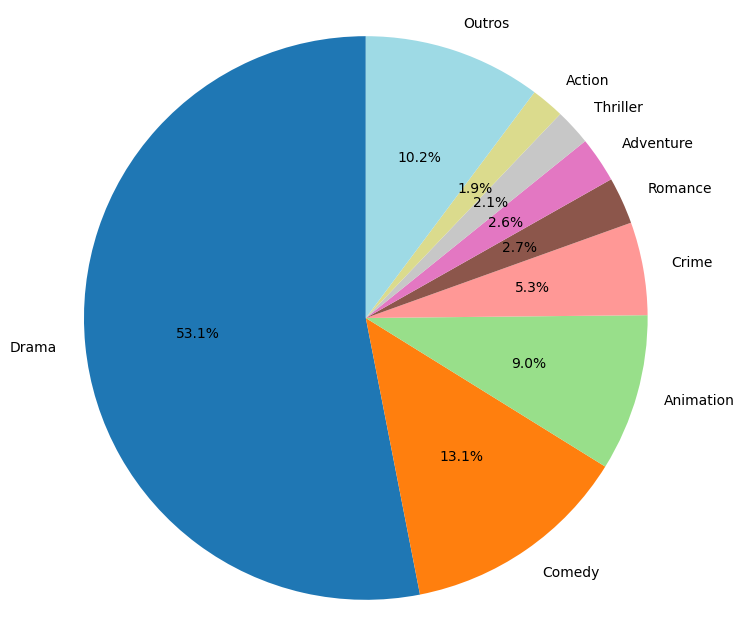

In [729]:
PizzaTopN(df_official_genre_percentual, 8)

In [730]:
df_best_picture_genre_count = DataFrameInfoTotalCount(df_best_picture, "Genre")

In [731]:
df_best_picture_genre_percentual = DataFrameInfoPercentual(df_best_picture, "Genre")

In [732]:
df_international_genre_count = DataFrameInfoTotalCount(df_international_film, "Genre")

display(df_international_genre_count)


,count
Genre,
Drama,179
Comedy,42
Romance,11
Crime,10
War,8
Adventure,8
Action,6
Documentary,5
History,5


In [733]:
df_international_genre_percentual = DataFrameInfoPercentual(df_international_film, "Genre")
display(df_international_genre_percentual)

,Genre,Percentual
0,Drama,62.37
1,Comedy,14.63
2,Romance,3.83
3,Crime,3.48
4,War,2.79
5,Adventure,2.79
6,Action,2.09
7,Documentary,1.74
8,History,1.74
9,Horror,0.70


In [734]:
df_exploded = df_Official.explode("Birth Country").dropna(subset=["Birth Country"]).reset_index(drop=True)
df_official_birth_country_count = DataFrameInfoTotalCount(df_exploded, "Birth Country")
display(df_official_birth_country_count)


,count
Birth Country,
USA,2154
UK,509
France,78
Canada,67
Italy,59
...,...
Bulgarian,1
Korea,1
Vietnam,1


In [735]:
df_official_birth_country_percentual = DataFrameInfoPercentual(df_exploded, "Birth Country")
display(df_official_birth_country_percentual)

,Birth Country,Percentual
0,USA,64.53
1,UK,15.25
2,France,2.34
3,Canada,2.01
4,Italy,1.77
...,...,...
64,Bulgarian,0.03
65,Korea,0.03
66,Vietnam,0.03
67,Malaysia,0.03


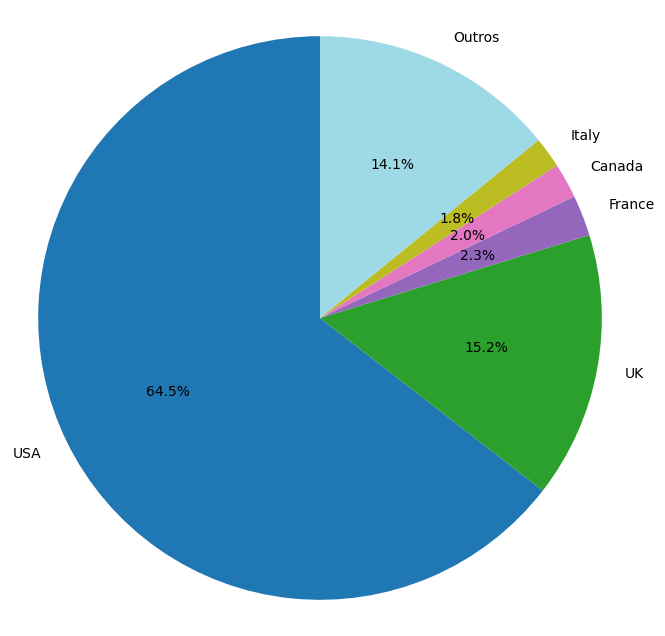

In [736]:
PizzaTopN(df_official_birth_country_percentual, 5)

In [737]:
def show_raw_data_count_for_year(df, collum):
  df_count = (
    df.groupby(["Year", collum])
    .size()  # conta número de linhas por grupo
    .reset_index(name="Count")
  )
  return df_count

In [738]:
import pandas as pd
import math

def floor_2(x):
    return math.floor(x * 100) / 100

def calculate_basics_analitics(df, collum):
  data_analytics = df.groupby(collum)['Count'].agg(
      Média=lambda x: floor_2(x.mean()),
      Mediana='median',
      Moda=lambda x: x.mode().tolist(),
      Amplitude = lambda x: x.max() - x.min(),
      Desvio = lambda x: x.std()
  ).reset_index()
  return data_analytics

In [739]:
df_genre_count = show_raw_data_count_for_year(df_Official, "Genre")
df_genre_data_analytics = calculate_basics_analitics(df_genre_count, "Genre")

In [740]:
display("Dados Brutos")
display(df_genre_count)
display("Dados Descritiveis")
display(df_genre_data_analytics)

'Dados Brutos'

,Year,Genre,Count
0,1927/28,Comedy,1
1,1927/28,Crime,1
2,1927/28,Drama,14
3,1927/28,War,1
4,1928/29,Comedy,1
...,...,...,...
694,2024,Drama,37
695,2024,Family,1
696,2024,History,2
697,2024,Horror,3


'Dados Descritiveis'

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,2.39,2.0,[1],9,1.836086
1,Adventure,2.57,2.0,[1],11,2.188026
2,Animation,4.01,4.0,[2],9,2.066790
3,Comedy,5.76,5.0,[1],17,3.963342
4,Crime,3.50,3.0,[1],12,2.539196
5,Documentary,1.11,1.0,[1],1,0.333333
6,Drama,22.67,23.0,[19],35,6.591854
7,Family,1.40,1.0,[1],3,0.797074
8,Fantasy,1.87,1.0,[1],5,1.408309
9,History,2.50,1.5,[1],5,1.888178


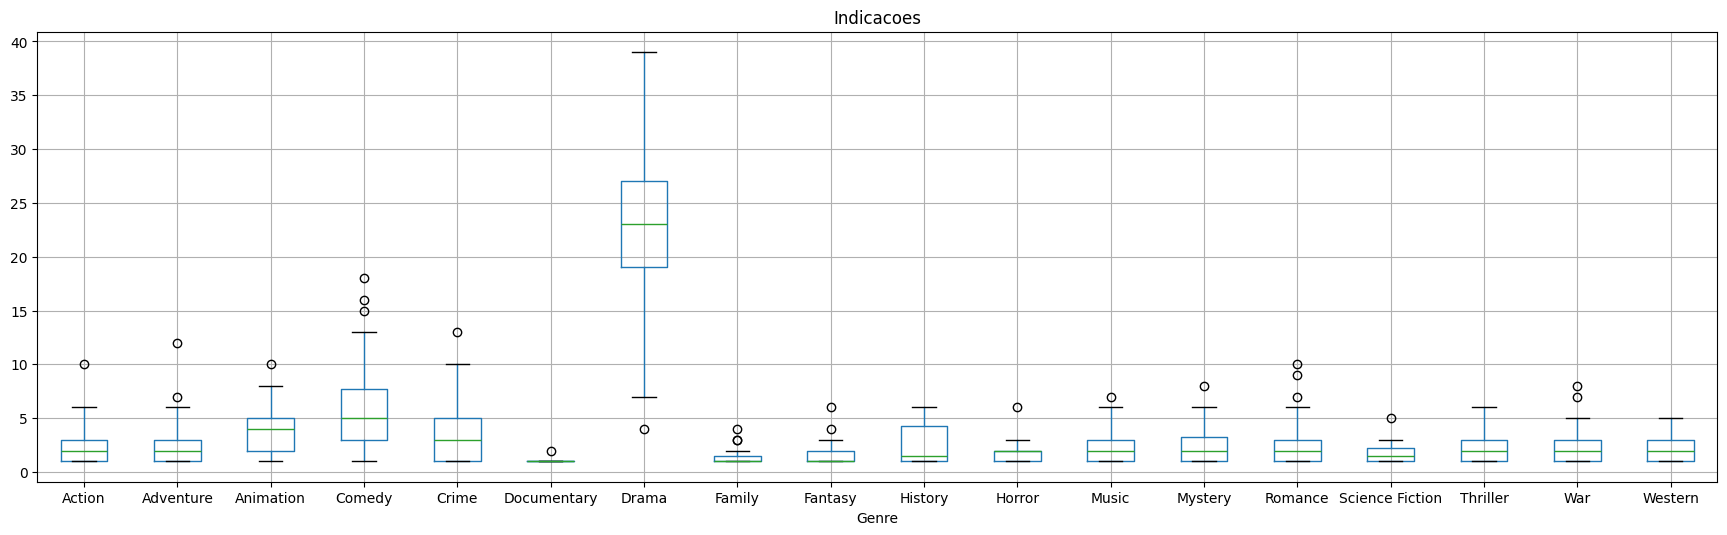

In [741]:
import matplotlib.pyplot as plt

resultado = df_Official.groupby(['Year','Genre']).size().reset_index(name='Indicacoes')

top_generos = resultado.groupby('Genre')['Indicacoes'].sum().nlargest(20).index

dados_top = resultado[resultado['Genre'].isin(top_generos)]

dados_top.boxplot(column='Indicacoes', by='Genre', figsize=(21,6))
plt.suptitle("")
plt.show()

In [742]:
lastYear = 2024
df_exploded = df_Official.explode("Birth Country").dropna(subset=["Birth Country"]).reset_index(drop=True)
paises = df_exploded["Birth Country"].unique()

df_year_range = (
    df_exploded.groupby("Birth Country")["Year"]
    .agg(["min", "max"])
    .reset_index()
)

df_year_range.columns = ["Birth Country", "First Year", "Last Year"]

df_year_range["Years Since Last Indication"] = lastYear - df_year_range["Last Year"].str.split("/").str[0].astype(int)
display(df_year_range)

,Birth Country,First Year,Last Year,Years Since Last Indication
0,Argentina,1930/31,2011,13
1,Australia,1932/33,2023,1
2,Austria,1930/31,2012,12
3,Austria-Hungary,1939,1974,50
4,Belarus,1930/31,1930/31,94
...,...,...,...,...
64,UK,1927/28,2024,0
65,USA,1927/28,2024,0
66,Uganda,1996,1996,28
67,Ukraine,1928/29,1966,58


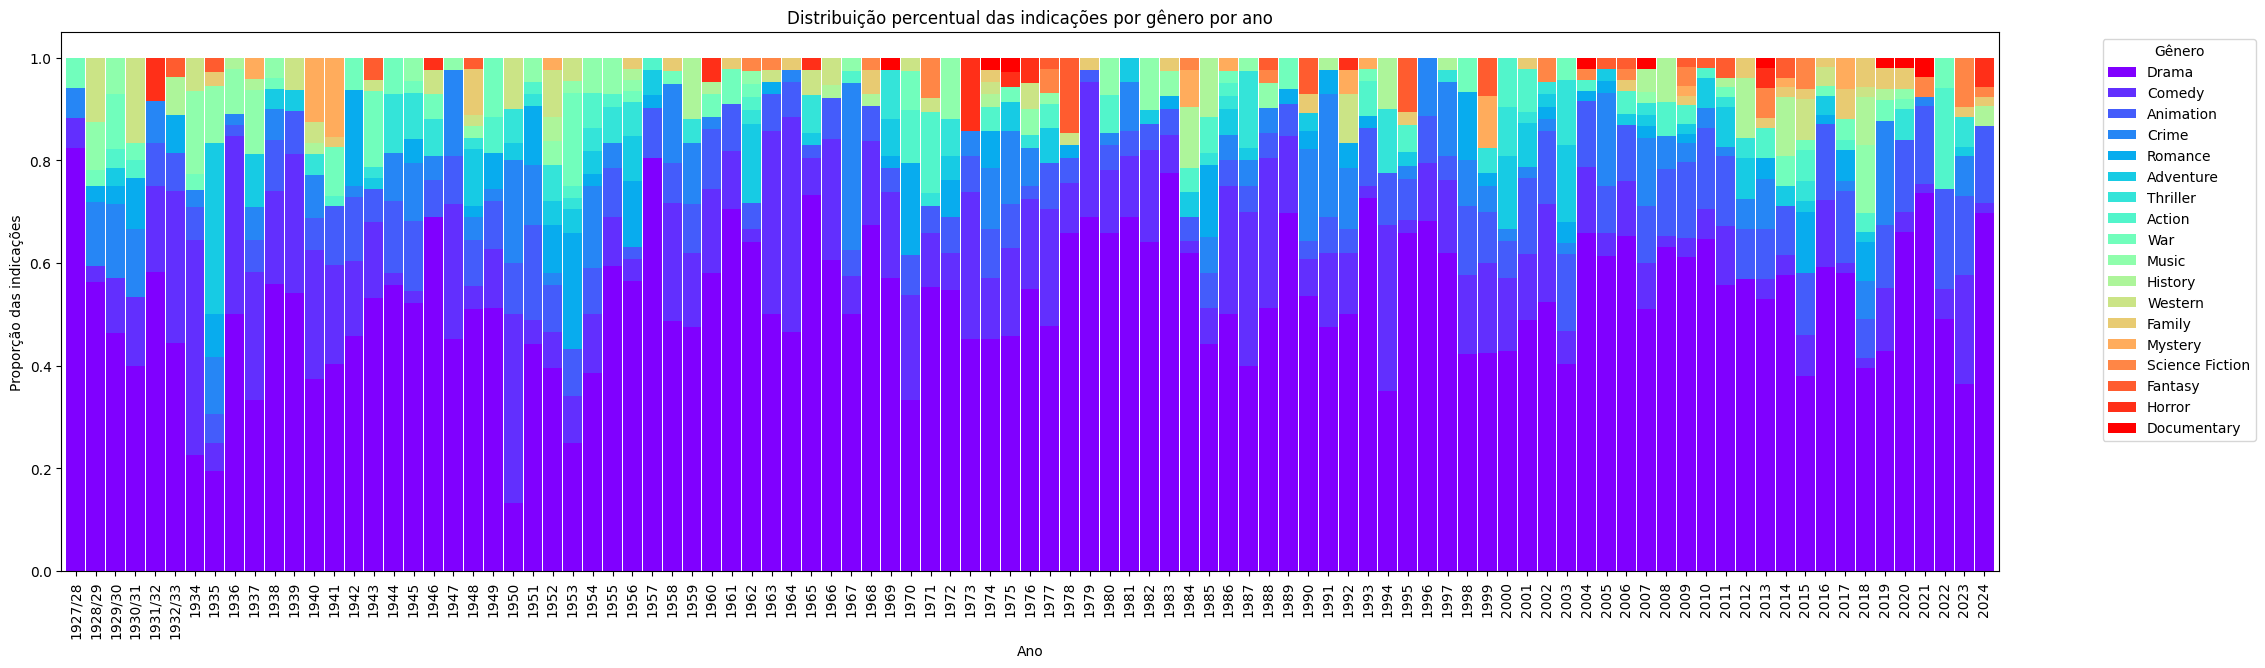

In [753]:
# contar indicações por ano e gênero
df_count = (
    df_Official
    .groupby(["Year", "Genre"])
    .size()
    .reset_index(name="Count")
)

# criar tabela ano x gênero
pivot = df_count.pivot(index="Year", columns="Genre", values="Count").fillna(0)

# ordenar gêneros pelo total (crescente)
ordem_generos = pivot.sum().sort_values(ascending=False).index
pivot = pivot[ordem_generos]

# transformar em porcentagem
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

# gráfico de colunas 100% empilhado
pivot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(25,7),
    width=0.95,
    colormap="rainbow"
)

plt.title("Distribuição percentual das indicações por gênero por ano")
plt.xlabel("Ano")
plt.ylabel("Proporção das indicações")

plt.legend(title="Gênero", bbox_to_anchor=(1.05,1))
plt.show()

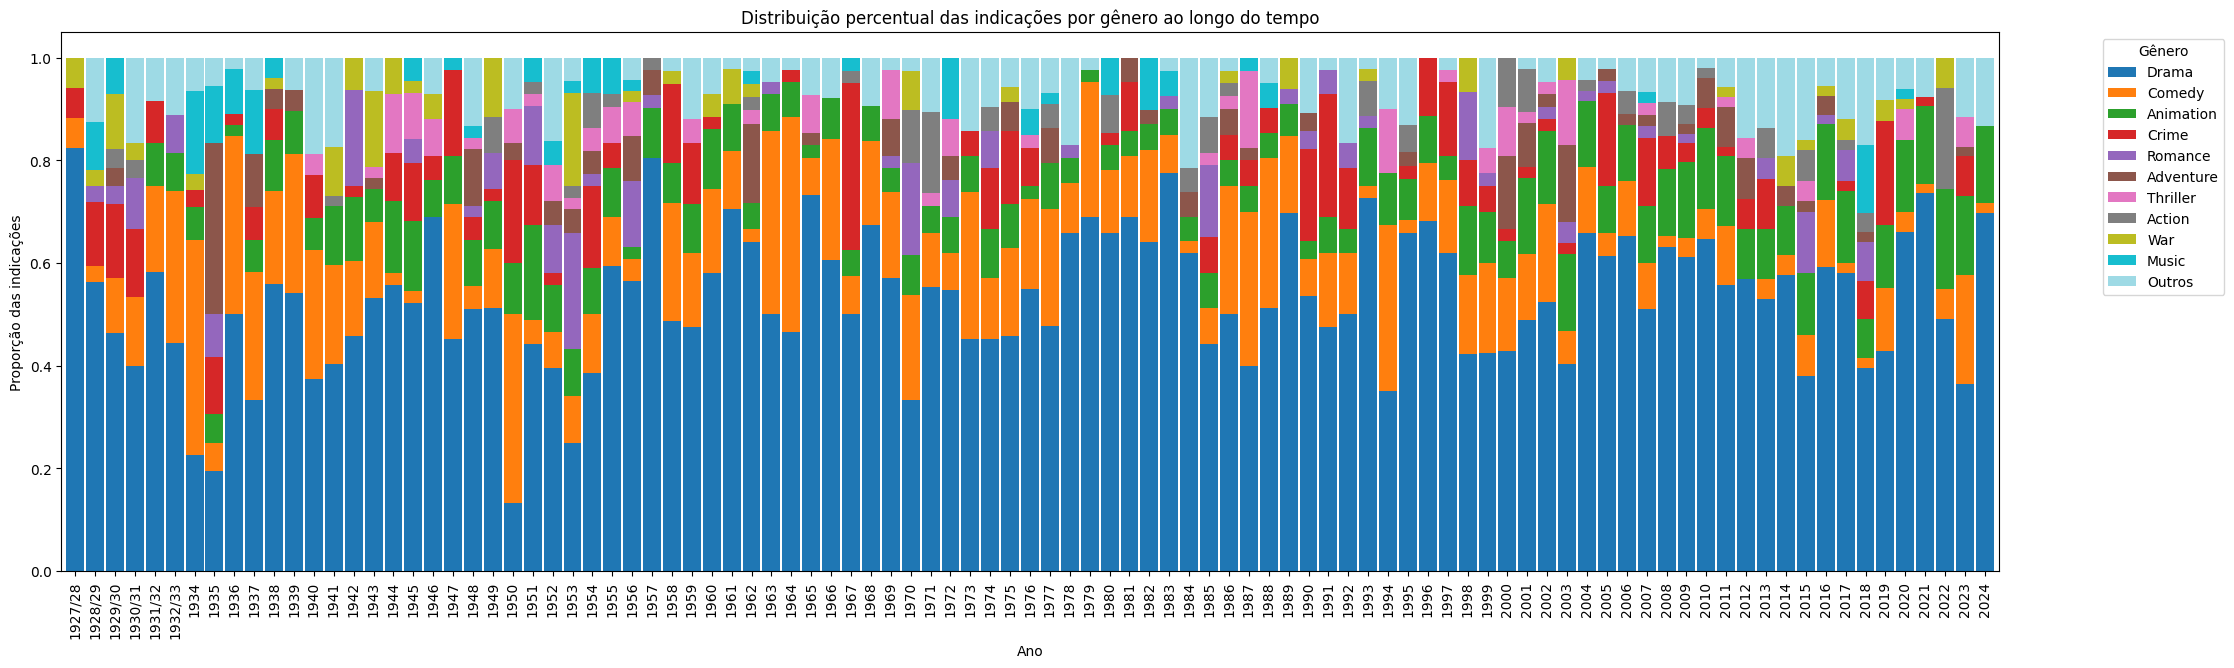

In [744]:
# contar indicações por ano e gênero
df_count = (
    df_Official
    .groupby(["Year", "Genre"])
    .size()
    .reset_index(name="Count")
)

# tabela ano x gênero
pivot = df_count.pivot(index="Year", columns="Genre", values="Count").fillna(0)

# descobrir os 10 gêneros mais indicados no TOTAL
top10 = pivot.sum().sort_values(ascending=False).head(10).index

# criar nova tabela só com os top5
pivot_top = pivot[top10].copy()

# somar todos os outros gêneros (total histórico restante)
outros = pivot.drop(columns=top10)

pivot_top["Outros"] = outros.sum(axis=1)

# transformar em porcentagem
pivot_pct = pivot_top.div(pivot_top.sum(axis=1), axis=0)

# gráfico 100% empilhado
pivot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(25,7),
    width=0.9,
    colormap="tab20"
)

plt.title("Distribuição percentual das indicações por gênero ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Proporção das indicações")

plt.legend(title="Gênero", bbox_to_anchor=(1.05,1))
plt.show()